# Income Pattern Data Analysis Using Visualization and Linear Regression

**Name:** Ravi Kumar Mishra  
**SAP ID:** 500122208

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [6]:
# Load Dataset
df = pd.read_csv('income_pattern.csv')
df.head()

,Annual_Income,Spending_Score
0,59.44,42.56
1,27.82,30.58
2,75.93,25.93
3,25.57,76.23
4,19.19,36.80


In [7]:
# Identify Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Numerical:', numerical_cols)
print('Categorical:', categorical_cols)

Numerical: ['Annual_Income', 'Spending_Score']
Categorical: []


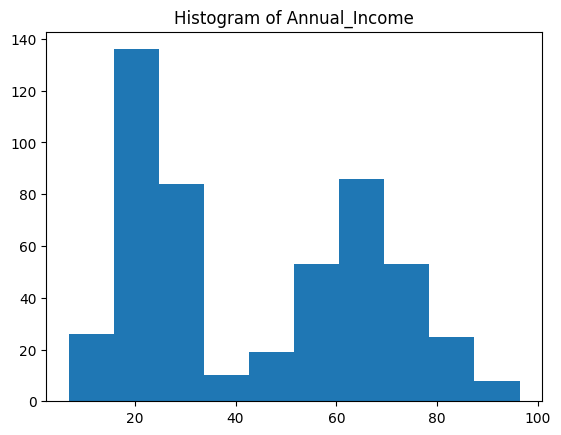

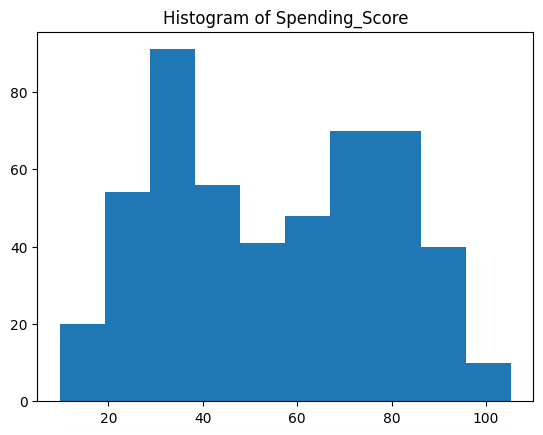

In [8]:
# Histograms
for col in numerical_cols:
    plt.figure()
    plt.hist(df[col])
    plt.title(f'Histogram of {col}')
    plt.show()

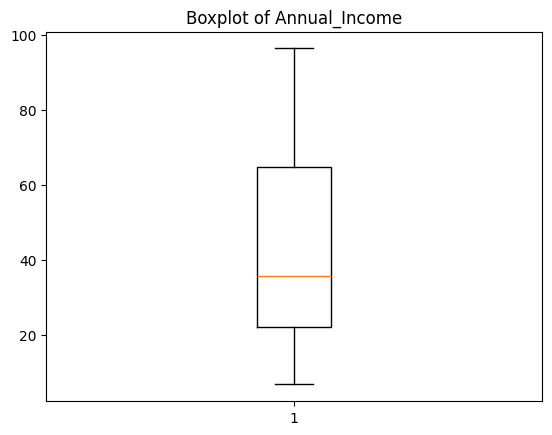

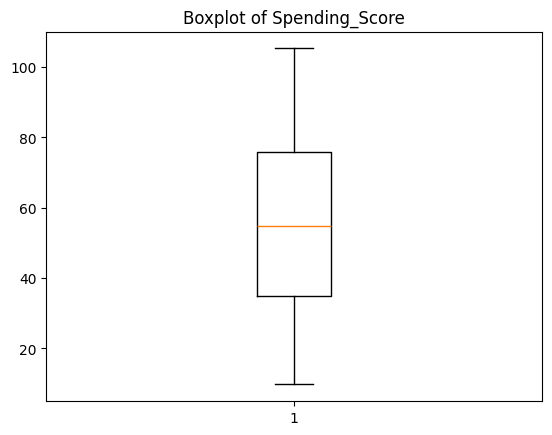

In [9]:
# Boxplots
for col in numerical_cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

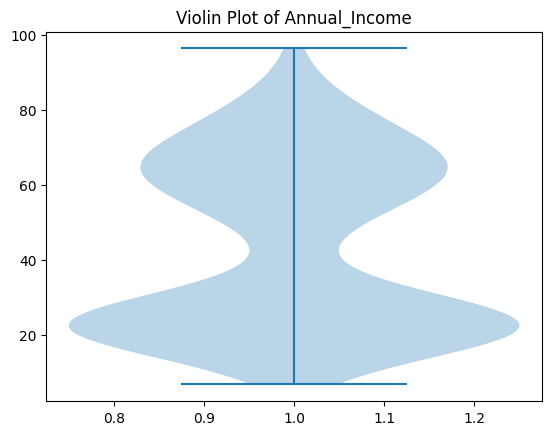

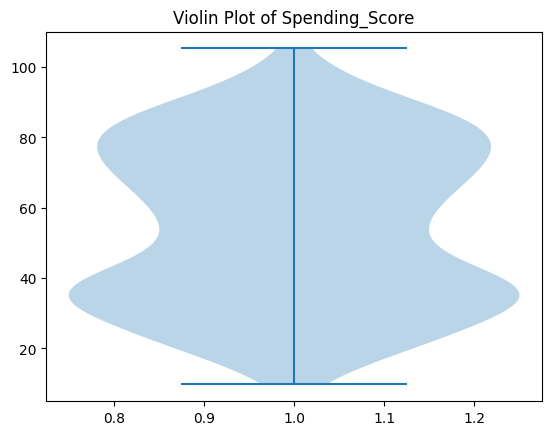

In [10]:
# Violin Plots
for col in numerical_cols:
    plt.figure()
    plt.violinplot(df[col])
    plt.title(f'Violin Plot of {col}')
    plt.show()

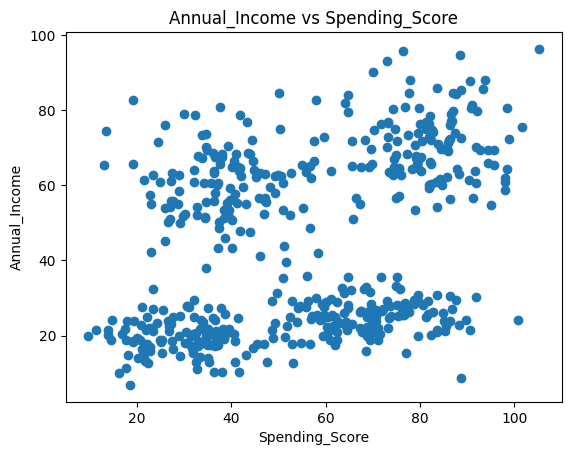

In [11]:
# Scatter Plot
target = 'Annual_Income'
for col in numerical_cols:
    if col != target:
        plt.figure()
        plt.scatter(df[col], df[target])
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f'{target} vs {col}')
        plt.show()

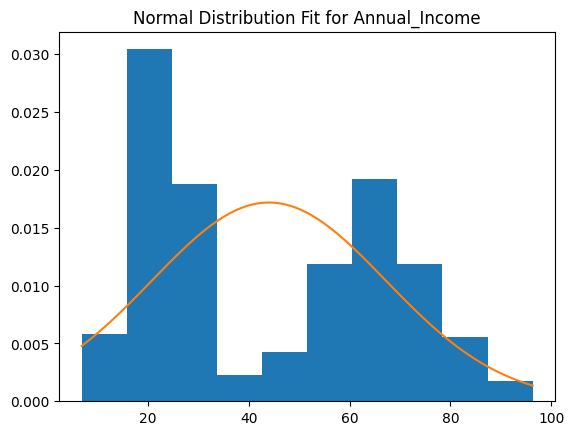

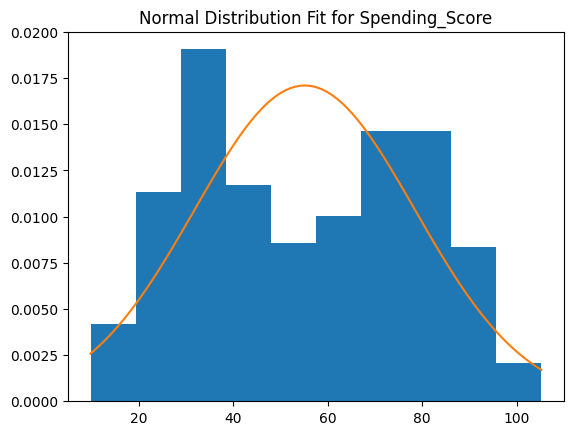

In [12]:
# Normal Distribution Fit
for col in numerical_cols:
    data = df[col]
    mean = np.mean(data)
    std = np.std(data)
    plt.figure()
    plt.hist(data, density=True)
    x = np.linspace(min(data), max(data), 100)
    normal_curve = (1/(std*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mean)/std)**2)
    plt.plot(x, normal_curve)
    plt.title(f'Normal Distribution Fit for {col}')
    plt.show()

In [13]:
# Train-Test Split + Linear Regression
X = df[['Spending_Score']]
y = df['Annual_Income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('R2:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))

R2: 0.09219985873907621
MAE: 19.37275106296647
MSE: 448.1485011132339


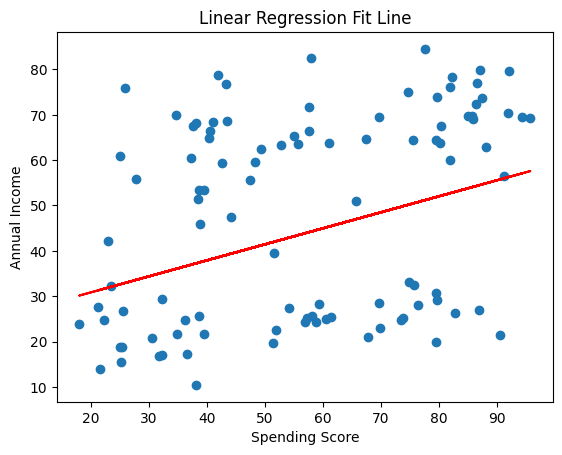

In [15]:
# Regression Fit Line (Spending Score vs Income)

plt.figure()
plt.scatter(X_test, y_test)

# 🔴 Regression line from model
plt.plot(X_test, y_pred, color='red')

plt.xlabel("Spending Score")
plt.ylabel("Annual Income")
plt.title("Linear Regression Fit Line")

plt.show()